In [ ]:
import pandas as pd

train_df = pd.read_csv('/content/drive/MyDrive/AIML_Project/Splits Stress_level_dataset/stress_level_train_featured.csv')
test_df = pd.read_csv('/content/drive/MyDrive/AIML_Project/Splits Stress_level_dataset/stress_level_test_featured.csv')

In [ ]:
feature_cols = [c for c in train_df.columns if c != "target"]

x_train = train_df[feature_cols]
y_train = train_df["target"]

x_test = test_df[feature_cols]
y_test = test_df["target"]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import DecisionBoundaryDisplay

In [ ]:
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

knn_preds = knn.predict(x_test)
knn_accuracy = accuracy_score(y_test, knn_preds)

print("KNN Accuracy:", knn_accuracy)
print(classification_report(y_test, knn_preds))

KNN Accuracy: 0.8590909090909091
              precision    recall  f1-score   support

           0       0.87      0.82      0.85        74
           1       0.83      0.93      0.88        72
           2       0.88      0.82      0.85        74

    accuracy                           0.86       220
   macro avg       0.86      0.86      0.86       220
weighted avg       0.86      0.86      0.86       220



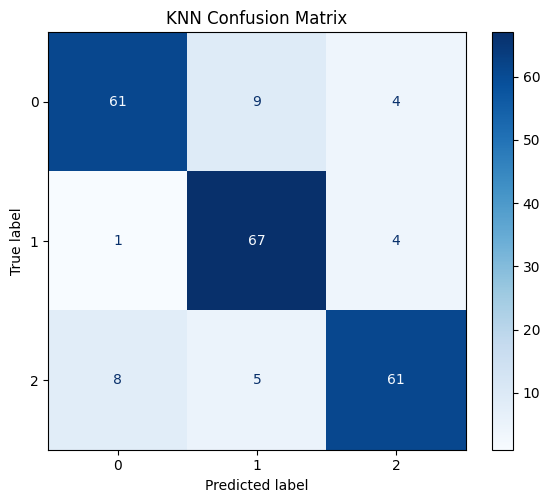

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_preds,
    cmap="Blues",
    ax=ax
)
ax.set_title("KNN Confusion Matrix")
plt.tight_layout()
plt.show()

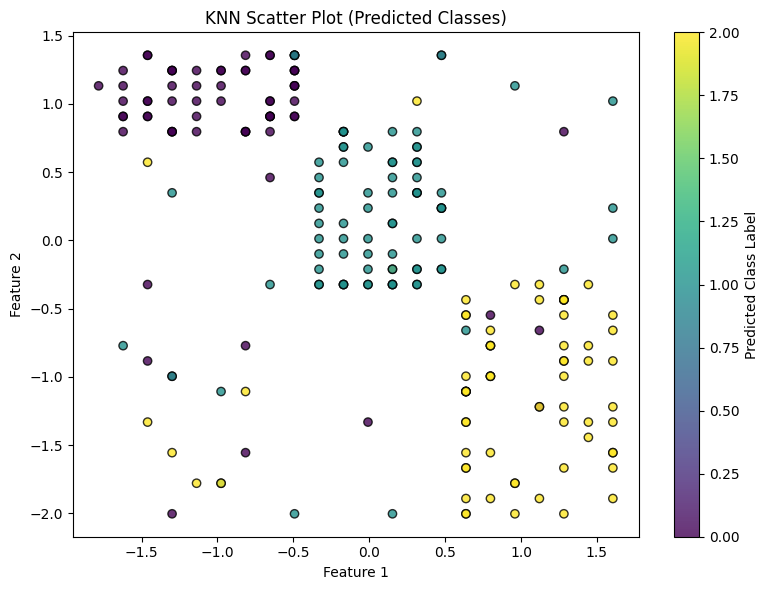

In [ ]:
X_test_np = x_test.values if hasattr(x_test, "values") else x_test

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    X_test_np[:, 0],
    X_test_np[:, 1],
    c=knn_preds,
    cmap="viridis",
    edgecolor="k",
    alpha=0.8
)

ax.set_title("KNN Scatter Plot (Predicted Classes)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.colorbar(scatter, label="Predicted Class Label")
plt.tight_layout()
plt.show()

In [ ]:
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(x_train, y_train)

print("Best KNN parameters:", grid_knn.best_params_)
print("Best KNN CV accuracy:", grid_knn.best_score_)

best_knn = grid_knn.best_estimator_
tuned_knn_preds = best_knn.predict(x_test)
tuned_knn_accuracy = accuracy_score(y_test, tuned_knn_preds)

print("Tuned KNN Test Accuracy:", tuned_knn_accuracy)
print(classification_report(y_test, tuned_knn_preds))

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best KNN parameters: {'metric': 'hamming', 'n_neighbors': 15, 'weights': 'distance'}
Best KNN CV accuracy: 0.878409090909091
Tuned KNN Test Accuracy: 0.8772727272727273
              precision    recall  f1-score   support

           0       0.88      0.81      0.85        74
           1       0.94      0.90      0.92        72
           2       0.82      0.92      0.87        74

    accuracy                           0.88       220
   macro avg       0.88      0.88      0.88       220
weighted avg       0.88      0.88      0.88       220



In [ ]:
#saving

In [ ]:
import joblib
preprocessor = joblib.load("/content/drive/MyDrive/AIML_Project/Model_Trained/preprocessor.pkl")

In [ ]:
joblib.dump(best_knn, '/content/drive/MyDrive/AIML_Project/Model_Trained/knn_model.pkl')

['/content/drive/MyDrive/AIML_Project/Model_Trained/knn_model.pkl']

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

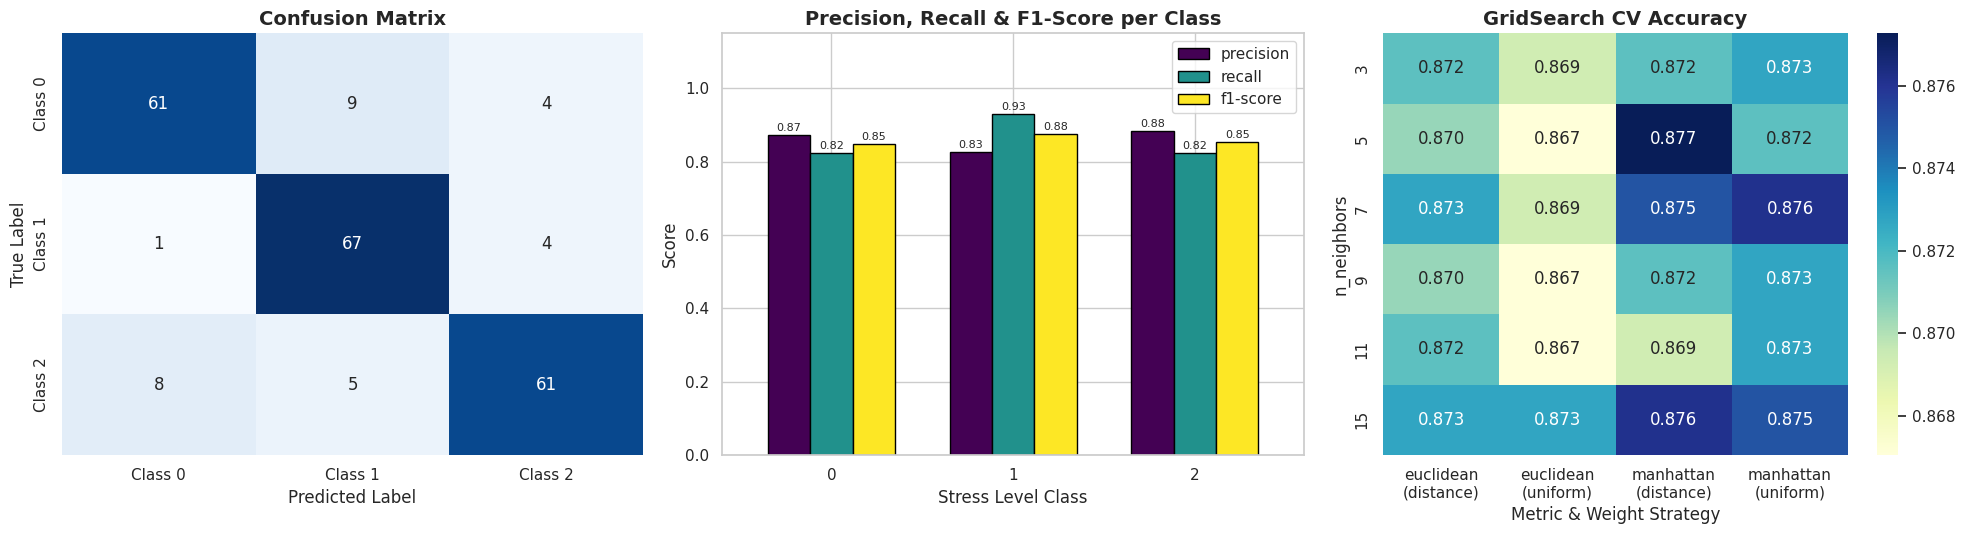

In [ ]:
# Set aesthetic styling
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# 1. CONFUSION MATRIX
cm = confusion_matrix(y_test, knn_preds)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[0],
    xticklabels=["Class 0", "Class 1", "Class 2"],
    yticklabels=["Class 0", "Class 1", "Class 2"],
)
axes[0].set_title("Confusion Matrix", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Predicted Label", fontsize=12)
axes[0].set_ylabel("True Label", fontsize=12)

# 2. CLASSIFICATION METRICS (Precision, Recall, F1-score)
report = classification_report(y_test, knn_preds, output_dict=True)
metrics_df = pd.DataFrame(report).transpose().iloc[:3, :3]  # Classes 0, 1, 2

metrics_df.plot(
    kind="bar", ax=axes[1], colormap="viridis", edgecolor="black", width=0.7
)
axes[1].set_title(
    "Precision, Recall & F1-Score per Class", fontsize=14, fontweight="bold"
)
axes[1].set_xlabel("Stress Level Class", fontsize=12)
axes[1].set_ylabel("Score", fontsize=12)
axes[1].set_ylim(0, 1.15)
axes[1].legend(loc="upper right", frameon=True)
axes[1].tick_params(axis="x", rotation=0)

# Add values above bars
for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 5),
        textcoords="offset points",
        fontsize=8,
    )

# 3. GRIDSEARCHCV ACCURACY HEATMAP
cv_results = pd.DataFrame(grid_knn.cv_results_)
cv_results["param_combination"] = (
    cv_results["param_metric"].astype(str)
    + "\n("
    + cv_results["param_weights"].astype(str)
    + ")"
)
pivot_scores = cv_results.pivot(
    index="param_n_neighbors",
    columns="param_combination",
    values="mean_test_score",
)

sns.heatmap(
    pivot_scores, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[2], cbar=True
)
axes[2].set_title("GridSearch CV Accuracy", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Metric & Weight Strategy", fontsize=12)
axes[2].set_ylabel("n_neighbors", fontsize=12)

plt.tight_layout()
plt.show()